# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

---

In [2]:
import pandas as pd
import matplotlib
import numpy
import seaborn
import plotly

## Base De Dados 

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).

In [4]:
df_original = pd.read_csv(r'.\aneel_classificacao_orange.csv')
df = df_original.copy()

In [23]:
for i in df.columns:
    print(i, df[i].isna().sum())

potencia_kw 0
latitude 0
longitude 0
fonte 0


In [25]:
df['fonte'].value_counts()

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

In [11]:
X = df.drop('fonte', axis=1)
X

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000
...,...,...,...
3871,2000.00,0.000000,0.000000
3872,1500.00,0.000000,0.000000
3873,710.00,0.000000,0.000000
3874,297.50,0.000000,0.000000


In [9]:
y = df['fonte']
y

0            Solar
1            Solar
2            Solar
3            Solar
4            Solar
           ...    
3871    Hidráulica
3872    Hidráulica
3873    Hidráulica
3874    Hidráulica
3875    Hidráulica
Name: fonte, Length: 3876, dtype: str

## Dividindo Teste e Treino

2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.

In [12]:
from sklearn.model_selection import train_test_split
# Métricas de avaliação para classificação
from sklearn.metrics import accuracy_score
     

In [15]:
seed_fixa = 42

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed_fixa)

In [26]:
X_train

,potencia_kw,latitude,longitude
177,30000.0,-13.320314,-43.372303
1924,27600.0,-2.639737,-42.636903
3250,1200.0,-24.889184,-49.591559
1620,28900.0,-7.423658,-40.671529
907,1.0,-1.794630,-52.973370
...,...,...,...
1130,1.0,-1.561550,-52.237130
1294,25600.0,-14.014750,-42.633861
860,1.0,-1.886020,-53.052410
3507,1000.0,-26.428417,-51.292139


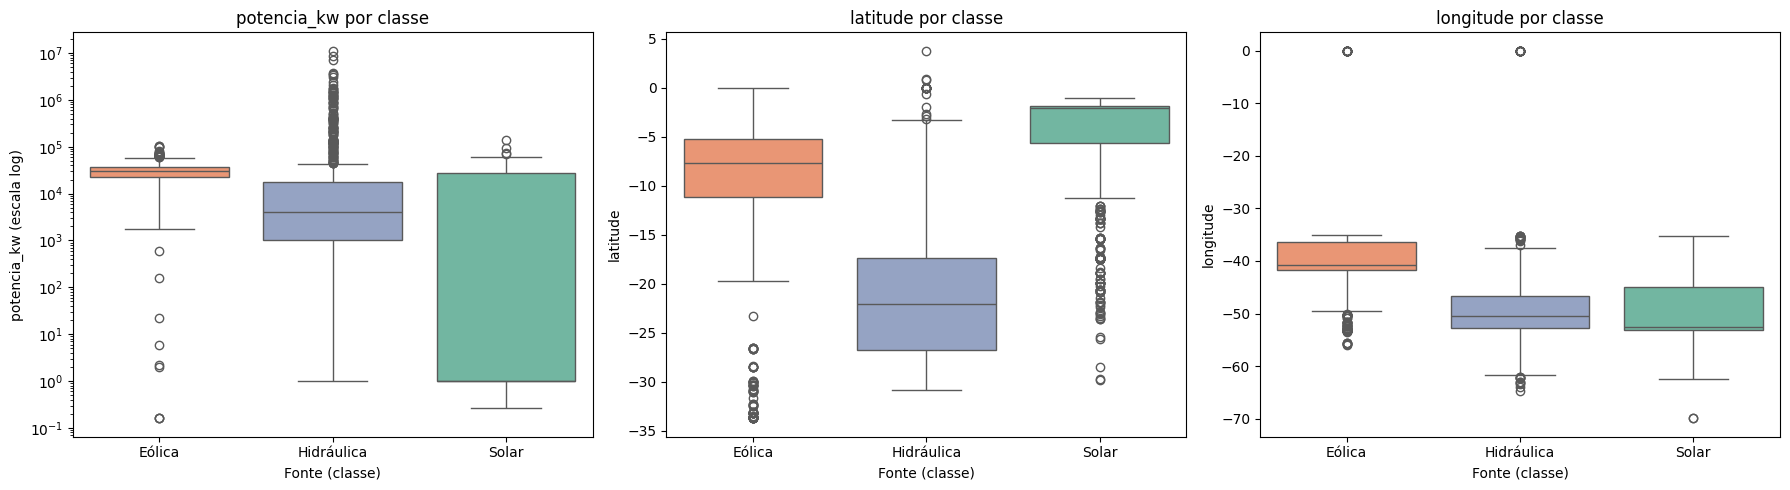

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = X_train.copy()
df_plot["fonte"] = y_train.values
ordem = sorted(df_plot["fonte"].unique())

colunas = ["potencia_kw", "latitude", "longitude"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, colunas):
    sns.boxplot(data=df_plot, x="fonte", y=col, order=ordem,
                hue="fonte", palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col} por classe")
    ax.set_xlabel("Fonte (classe)")

axes[0].set_yscale("log")  # potência é muito assimétrica; escala log evita achatar as caixas
axes[0].set_ylabel("potencia_kw (escala log)")

plt.tight_layout()
plt.show()

---

3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.

In [ ]:
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import RidgeClassifier

resultados = {}

def avaliar(nome, modelo):
    pipe = make_pipeline(StandardScaler(), modelo)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    resultados[nome] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall":    recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1":        f1_score(y_test, y_pred, average="macro", zero_division=0),
    }
    print(nome)
    for k, v in resultados[nome].items():
        print(f"  {k}: {v:.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.

GaussianProcessClassifier
  Accuracy: 0.8297
  Precision: 0.8413
  Recall: 0.8301
  F1: 0.8233


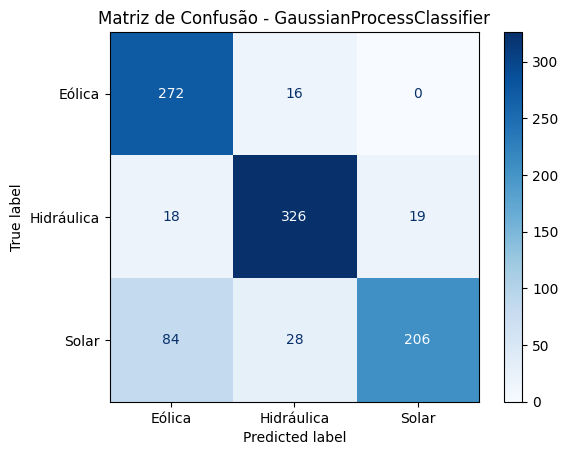

In [28]:
avaliar("GaussianProcessClassifier", GaussianProcessClassifier(random_state=seed_fixa))

BernoulliNB
  Accuracy: 0.7637
  Precision: 0.7788
  Recall: 0.7584
  F1: 0.7562


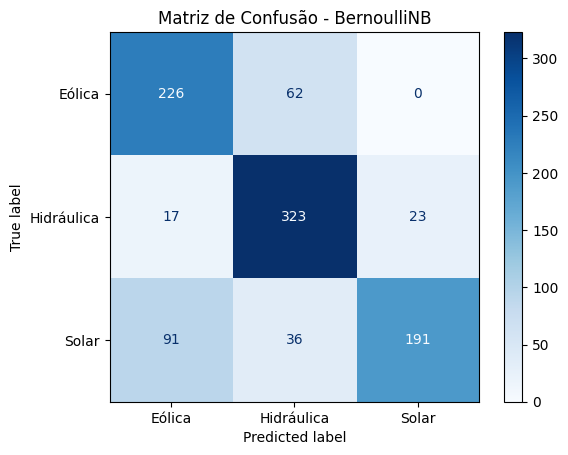

In [29]:
avaliar("BernoulliNB", BernoulliNB())

RidgeClassifier
  Accuracy: 0.7761
  Precision: 0.7819
  Recall: 0.7721
  F1: 0.7705


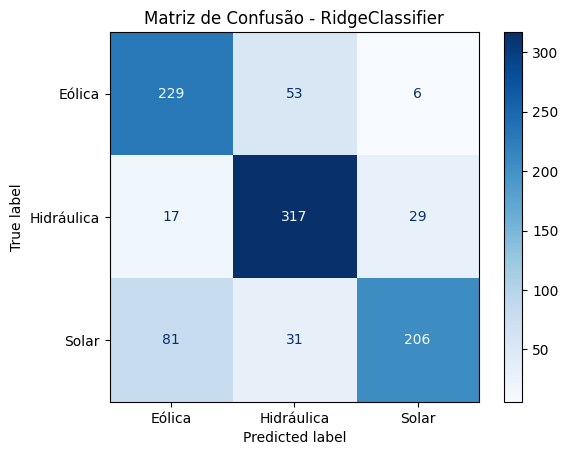

In [30]:
avaliar("RidgeClassifier", RidgeClassifier())

In [31]:
pd.DataFrame(resultados).T.round(4)

,Accuracy,Precision,Recall,F1
GaussianProcessClassifier,0.8297,0.8413,0.8301,0.8233
BernoulliNB,0.7637,0.7788,0.7584,0.7562
RidgeClassifier,0.7761,0.7819,0.7721,0.7705


---

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

1.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('meteo_regressao_orange.csv')

print("========== Linhas e Colunas ==========")
display(df.shape)

print("========== Info ==========")
display(df.info())

print("========== Describe ==========")
display(df.describe(include='number'))

========== Linhas e Colunas ==========


(1001, 7)

========== Info ==========
<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   str    
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), str(1)
memory usage: 54.9 KB


None

========== Describe ==========


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


In [ ]:
import plotly.express as px

# garante que a coluna é datetime
df["data"] = pd.to_datetime(df["data_hora"])

# agrega por dia
df_dia = (
    df.groupby(df["data"].dt.date)["radiacao_w_m2"]
    .mean()
    .reset_index()
)

fig = px.line(
    df_dia, x="data", y="radiacao_w_m2",
    markers=True,
    title="Radiação média por dia",
    labels={"data": "Data", "radiacao_w_m2": "Radiação (W/m²)"},
)
fig.show()

In [ ]:
df["data_hora"] = pd.to_datetime(df["data_hora"])

df_hora = (
    df.groupby(df["data_hora"].dt.hour)["radiacao_w_m2"]
    .mean()
    .reset_index()
    .rename(columns={"data_hora": "hora"})
)

fig = px.line(
    df_hora, x="hora", y="radiacao_w_m2",
    markers=True,
    title="Radiação média por hora do dia",
    labels={"hora": "Hora", "radiacao_w_m2": "Radiação (W/m²)"},
)
fig.update_xaxes(dtick=1)
fig.show()

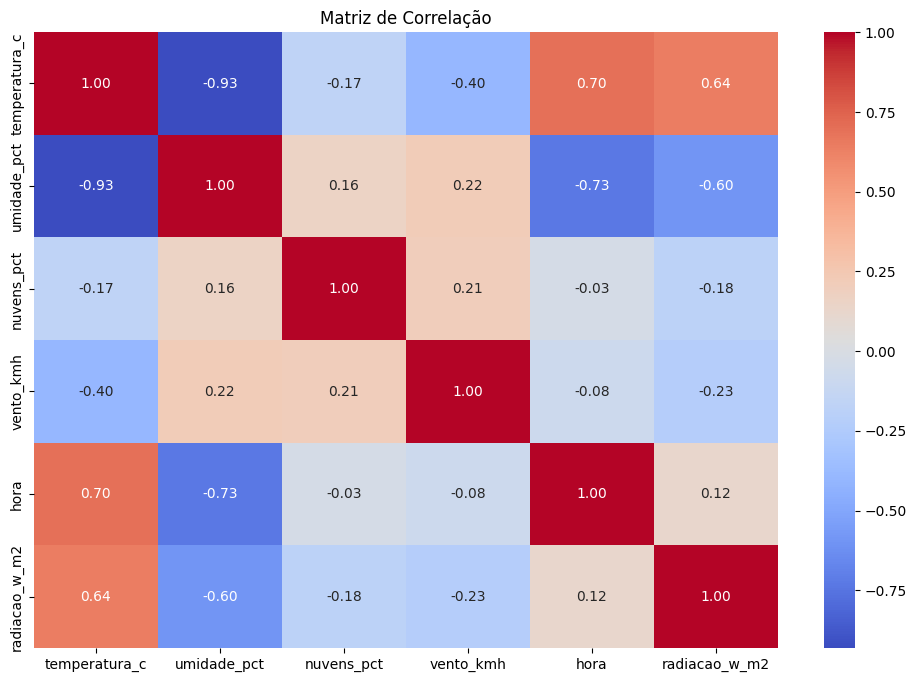

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cálculo da matriz de correlação das variáveis numéricas
correlacao = df.select_dtypes(include=[np.number]).corr()

# Exibição do mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()
     

As cinco variáveis selecionadas são: ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']
temperatura_c: correlação original = 0.6427
umidade_pct: correlação original = -0.5962
nuvens_pct: correlação original = -0.1802
vento_kmh: correlação original = -0.2294
hora: correlação original = 0.1201


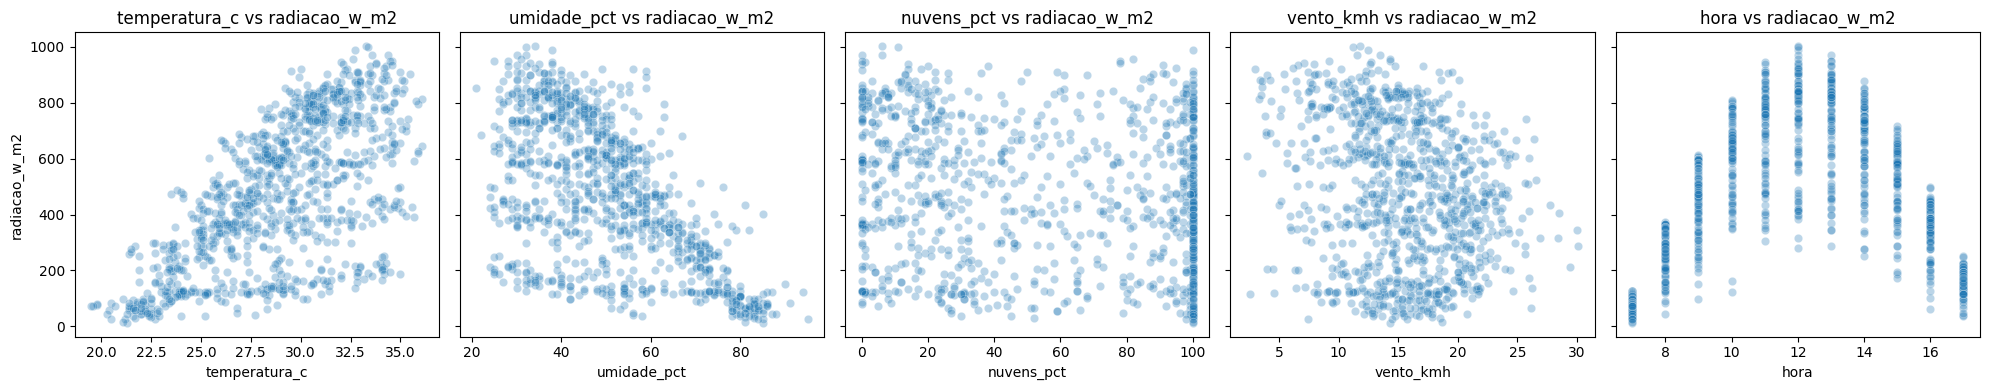

In [ ]:
cinco_variaveis = ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']
corr_stab = correlacao['radiacao_w_m2'].drop('radiacao_w_m2')

print("As cinco variáveis selecionadas são:", cinco_variaveis)
for col in cinco_variaveis:
    print(f"{col}: correlação original = {corr_stab[col]:.4f}")

# Geração dos gráficos de dispersão
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, col in enumerate(cinco_variaveis):
    sns.scatterplot(data=df, x=col, y='radiacao_w_m2', ax=axes[i], alpha=0.3)
    axes[i].set_title(f"{col} vs radiacao_w_m2")
    
plt.tight_layout()
plt.show()

2.

In [ ]:
df = df.sort_values(by='data_hora', ascending=True)

X = df[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']].copy()
y = df[['radiacao_w_m2']].copy()

In [ ]:
corte = int(len(df) * 0.8)
X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]

3 e 4

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definição dos modelos
modelos = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
}

# Treino e avaliação
resultados = []
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    previsoes[nome] = y_pred

    resultados.append({
        "Modelo": nome,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred),
    })

df_resultados = pd.DataFrame(resultados).sort_values("R²", ascending=False)
print(df_resultados.round(3))

c:\python314\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              Modelo      MAE     RMSE     R²
1      Random Forest   66.252   85.152  0.845
2  Gradient Boosting   64.223   85.214  0.845
0   Regressão Linear  145.205  173.304  0.360


c:\python314\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [ ]:
# formato longo: uma linha por (modelo, métrica)
df_metricas = df_resultados.melt(
    id_vars="Modelo",
    value_vars=["MAE", "RMSE", "R²"],
    var_name="Métrica",
    value_name="Valor",
)

fig = px.bar(
    df_metricas, x="Modelo", y="Valor",
    color="Modelo",
    facet_col="Métrica",
    text_auto=".3f",
    title="Comparação das métricas dos modelos",
)
fig.update_yaxes(matches=None, showticklabels=True)  # cada métrica com sua escala
fig.update_xaxes(title_text="")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # limpa "Métrica=MAE"
fig.update_layout(showlegend=False)
fig.show()

### Métricas

- **MAE:** erro médio das previsões, na mesma unidade da radiação (W/m²). **Quanto menor, melhor.**
- **RMSE:** parecido com o MAE, mas dá mais peso aos erros grandes. **Quanto menor, melhor.**
- **R²:** mostra o quanto o modelo explica os dados (de 0 a 1). **Quanto maior, melhor.**

**Resumo:** o melhor modelo é o que tem as barras de MAE e RMSE mais baixas e a barra de R² mais alta.

5.

In [ ]:

melhor = modelos["Random Forest"]
y_pred = melhor.predict(X_test)

df_erro = pd.DataFrame({
    "data_hora": df["data_hora"].iloc[corte:].values,
    "real": y_test['radiacao_w_m2'].values,
    "previsto": y_pred,
})
df_erro["erro"] = df_erro["real"] - df_erro["previsto"]
df_erro["erro_abs"] = df_erro["erro"].abs()
df_erro["hora"] = pd.to_datetime(df_erro["data_hora"]).dt.hour

# erro médio absoluto por hora do dia
erro_hora = df_erro.groupby("hora")["erro_abs"].mean().reset_index()

fig = px.bar(erro_hora, x="hora", y="erro_abs",
             title="Erro médio absoluto por hora do dia",
             labels={"hora": "Hora", "erro_abs": "MAE (W/m²)"})
fig.update_xaxes(dtick=1)
fig.show()

In [ ]:
fig = px.line(df_erro, x="data_hora", y=["real", "previsto"],
              title="Real vs. previsto no período de teste")
fig.show()

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(melhor, X_test, y_test,
                              n_repeats=10, random_state=42, scoring="r2")

df_imp = pd.DataFrame({"variavel": X.columns, "importancia": perm.importances_mean}) \
           .sort_values("importancia")

fig = px.bar(df_imp, x="importancia", y="variavel", orientation="h",
             title="Importância das variáveis (queda no R² ao embaralhar)")
fig.show()

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)